# Podcast Dinleme Süresi Tahmini

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSPdiPQIK-CePOzK1oETpsL65N1BeFs_Nh1rg&s">

### Sütun Açıklamaları

**Podcast_Name:** Podcast’in adını belirtir.

**Episode_Title:** Podcast bölümünün başlığını gösterir.

**Episode_Length_minutes:** Bölümün toplam süresini dakika cinsinden ifade eder.

**Genre:** Podcast’in ait olduğu kategori veya türü belirtir.

**Host_Popularity_percentage:** Sunucunun popülerliğini yüzde cinsinden gösterir.

**Publication_Day:** Bölümün haftanın hangi günü yayınlandığını belirtir.

**Publication_Time:** Bölümün gün içinde hangi saatte yayınlandığını gösterir.

**Guest_Popularity_percentage:** Bölümde yer alan konuğun popülerliğini yüzde cinsinden ifade eder.

**Number_of_Ads:** Bölüm içinde bulunan reklam sayısını gösterir.

**Episode_Sentiment:** Bölümün genel duygu tonunu (pozitif, negatif, nötr vb.) ifade eder.

**Listening_Time_minutes:** Dinleyicilerin bölümü ortalama kaç dakika dinlediğini gösteren hedef değişkendir.

### Veri seti
https://www.kaggle.com/datasets/ysthehurricane/podcast-listening-time-prediction-dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/podcastdinlemesuresitahmini/podcast_dataset.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error



In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/podcastdinlemesuresitahmini/podcast_dataset.csv")

df.head()


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Healthy Living,Episode 77,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695
1,Mystery Matters,Episode 6,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559
2,Current Affairs,Episode 1,117.03,News,96.33,Sunday,Night,57.95,3,Neutral,110.064645
3,Mystery Matters,Episode 38,16.97,True Crime,25.73,Monday,Night,24.19,0,Positive,12.000380
4,Humor Hub,Episode 73,83.48,Comedy,76.69,Tuesday,Afternoon,42.31,3,Positive,NaN


In [4]:
df.shape

(52500, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Podcast_Name                 52500 non-null  object 
 1   Episode_Title                52500 non-null  object 
 2   Episode_Length_minutes       47254 non-null  float64
 3   Genre                        52500 non-null  object 
 4   Host_Popularity_percentage   52500 non-null  float64
 5   Publication_Day              52500 non-null  object 
 6   Publication_Time             52500 non-null  object 
 7   Guest_Popularity_percentage  47242 non-null  float64
 8   Number_of_Ads                52500 non-null  int64  
 9   Episode_Sentiment            52500 non-null  object 
 10  Listening_Time_minutes       47105 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ MB


In [6]:
df.describe()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,47254.000000,52500.000000,47242.000000,52500.000000,47105.000000
mean,62.853491,60.163949,50.053434,1.497962,45.560293
std,33.137428,23.158567,28.884997,1.117412,27.182454
min,5.000000,20.000000,0.010000,0.000000,0.000000
25%,34.300000,40.000000,25.030000,0.000000,23.286442
50%,62.870000,60.300000,50.035000,1.000000,43.555490
75%,91.550000,80.310000,75.100000,2.000000,64.953793
max,120.000000,100.000000,100.000000,3.000000,119.970000


In [7]:
df.corr(numeric_only=True)

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
Episode_Length_minutes,1.000000,0.002295,0.001020,0.009164,0.902019
Host_Popularity_percentage,0.002295,1.000000,0.000450,-0.004012,0.047143
Guest_Popularity_percentage,0.001020,0.000450,1.000000,0.010278,-0.004655
Number_of_Ads,0.009164,-0.004012,0.010278,1.000000,-0.087119
Listening_Time_minutes,0.902019,0.047143,-0.004655,-0.087119,1.000000


In [8]:
df.columns

Index(['Podcast_Name', 'Episode_Title', 'Episode_Length_minutes', 'Genre',
       'Host_Popularity_percentage', 'Publication_Day', 'Publication_Time',
       'Guest_Popularity_percentage', 'Number_of_Ads', 'Episode_Sentiment',
       'Listening_Time_minutes'],
      dtype='object')

In [9]:
df.isnull().sum()

Podcast_Name                      0
Episode_Title                     0
Episode_Length_minutes         5246
Genre                             0
Host_Popularity_percentage        0
Publication_Day                   0
Publication_Time                  0
Guest_Popularity_percentage    5258
Number_of_Ads                     0
Episode_Sentiment                 0
Listening_Time_minutes         5395
dtype: int64

In [10]:
df = df.dropna(subset=["Listening_Time_minutes"])


In [11]:
df["Episode_Length_minutes"].fillna(
    df["Episode_Length_minutes"].median(),
    inplace=True
)


In [12]:
df["Guest_Popularity_percentage"].fillna(
    df["Guest_Popularity_percentage"].median(),
    inplace=True
)


In [13]:
df["Guest_missing_flag"] = df["Guest_Popularity_percentage"].isnull().astype(int)

df["Guest_Popularity_percentage"].fillna(
    df["Guest_Popularity_percentage"].median(),
    inplace=True
)


In [14]:
df.isnull().sum()

Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
Guest_missing_flag             0
dtype: int64

In [15]:
df["pub_hour"] = pd.to_datetime(df["Publication_Time"], errors="coerce").dt.hour


In [16]:
df["ads_per_minute"] = df["Number_of_Ads"] / df["Episode_Length_minutes"]


In [17]:
df["host_guest_interaction"] = (
    df["Host_Popularity_percentage"] *
    df["Guest_Popularity_percentage"]
)


In [18]:
df["is_weekend"] = df["Publication_Day"].isin(["Saturday","Sunday"]).astype(int)


In [19]:
df["length_category"] = pd.cut(
    df["Episode_Length_minutes"],
    bins=[0,20,40,60,120,500],
    labels=["Very_Short","Short","Medium","Long","Very_Long"]
)


In [20]:
df = df.drop(["Podcast_Name","Episode_Title"], axis=1)


In [21]:
df.head()



,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Guest_missing_flag,pub_hour,ads_per_minute,host_guest_interaction,is_weekend,length_category
0,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695,0,NaN,0.030227,1500.6014,0,Long
1,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559,0,NaN,0.051467,3546.3285,0,Very_Short
2,117.03,News,96.33,Sunday,Night,57.95,3,Neutral,110.064645,0,NaN,0.025634,5582.3235,1,Long
3,16.97,True Crime,25.73,Monday,Night,24.19,0,Positive,12.000380,0,NaN,0.000000,622.4087,0,Very_Short
5,28.06,Business,22.02,Wednesday,Morning,50.12,1,Neutral,13.913024,0,NaN,0.035638,1103.6424,0,Short


In [22]:
df.isnull().sum()

Episode_Length_minutes             0
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage        0
Number_of_Ads                      0
Episode_Sentiment                  0
Listening_Time_minutes             0
Guest_missing_flag                 0
pub_hour                       47105
ads_per_minute                     0
host_guest_interaction             0
is_weekend                         0
length_category                    0
dtype: int64

In [23]:
# pub_hour'u silelim
df = df.drop("pub_hour", axis=1)

# Publication_Time zaten kategorik, model için kullanacağız


In [24]:
df["Publication_Time"].unique()[:20]


array(['Night', 'Evening', 'Morning', 'Afternoon'], dtype=object)

In [25]:
time_map = {
    "Morning": 0,
    "Afternoon": 1,
    "Evening": 2,
    "Night": 3
}

df["pub_time_encoded"] = df["Publication_Time"].map(time_map)


In [26]:
df = df.drop("Publication_Time", axis=1)


In [27]:
df.head()

,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Guest_missing_flag,ads_per_minute,host_guest_interaction,is_weekend,length_category,pub_time_encoded
0,99.25,Health,21.37,Thursday,70.22,3,Positive,55.158695,0,0.030227,1500.6014,0,Long,3
1,19.43,True Crime,47.19,Friday,75.15,1,Neutral,7.686559,0,0.051467,3546.3285,0,Very_Short,2
2,117.03,News,96.33,Sunday,57.95,3,Neutral,110.064645,0,0.025634,5582.3235,1,Long,3
3,16.97,True Crime,25.73,Monday,24.19,0,Positive,12.000380,0,0.000000,622.4087,0,Very_Short,3
5,28.06,Business,22.02,Wednesday,50.12,1,Neutral,13.913024,0,0.035638,1103.6424,0,Short,0


In [28]:
df.isnull().sum()

Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
Guest_missing_flag             0
ads_per_minute                 0
host_guest_interaction         0
is_weekend                     0
length_category                0
pub_time_encoded               0
dtype: int64

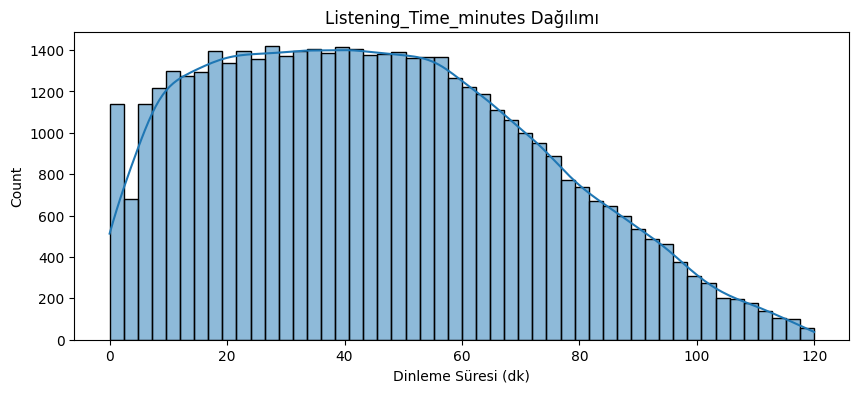

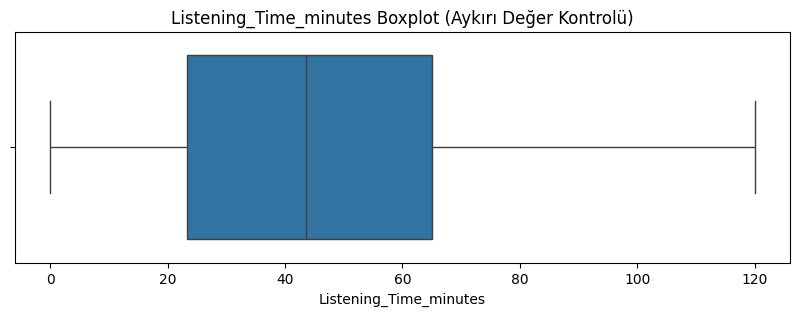

In [29]:
plt.figure(figsize=(10,4))
sns.histplot(df["Listening_Time_minutes"], bins=50, kde=True)
plt.title("Listening_Time_minutes Dağılımı")
plt.xlabel("Dinleme Süresi (dk)")
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=df["Listening_Time_minutes"])
plt.title("Listening_Time_minutes Boxplot (Aykırı Değer Kontrolü)")
plt.show()


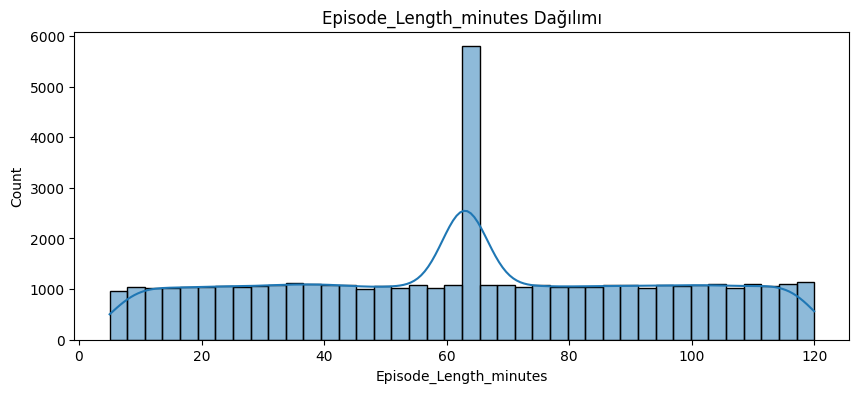

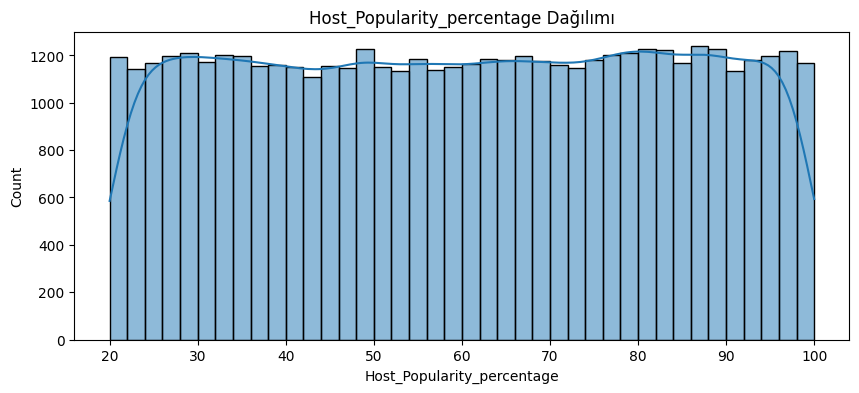

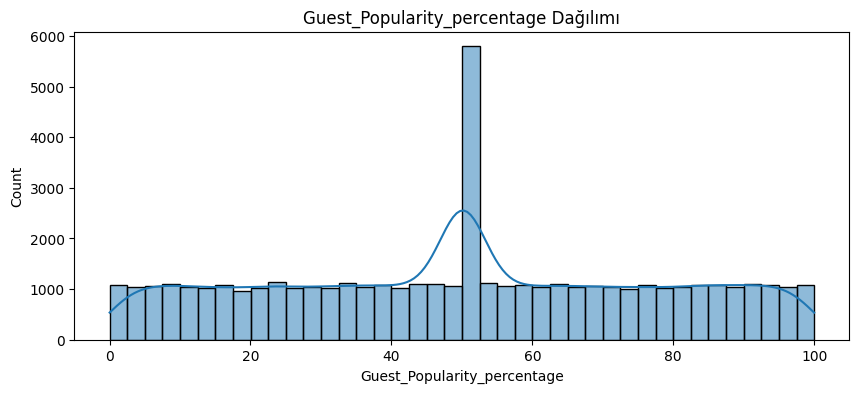

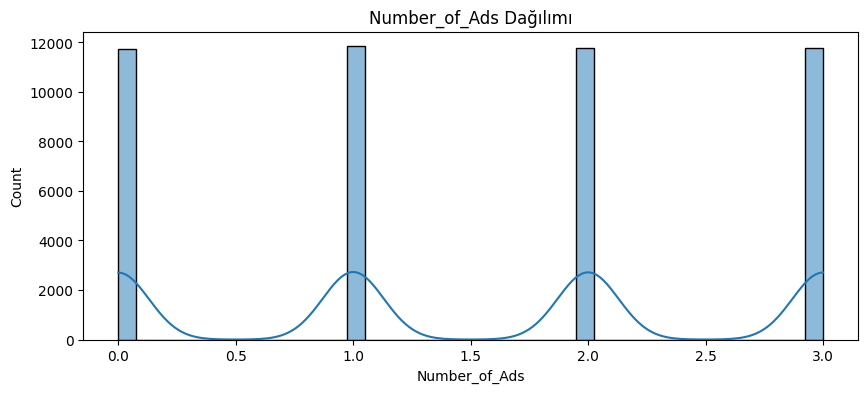

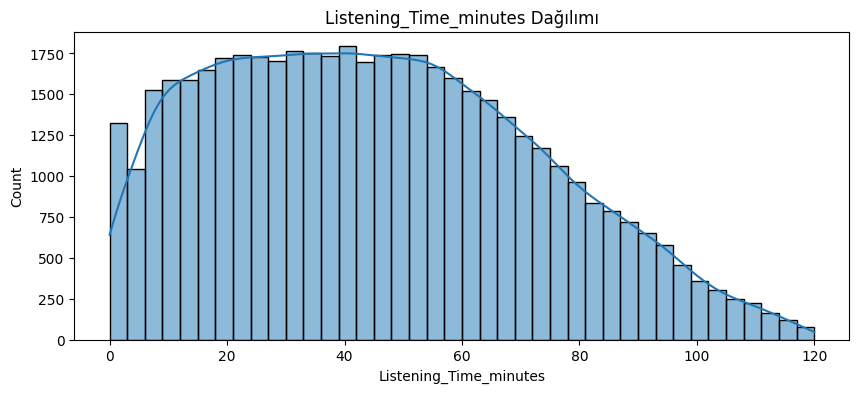

In [30]:
num_cols = ["Episode_Length_minutes","Host_Popularity_percentage",
            "Guest_Popularity_percentage","Number_of_Ads","Listening_Time_minutes"]

for col in num_cols:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"{col} Dağılımı")
    plt.xlabel(col)
    plt.show()


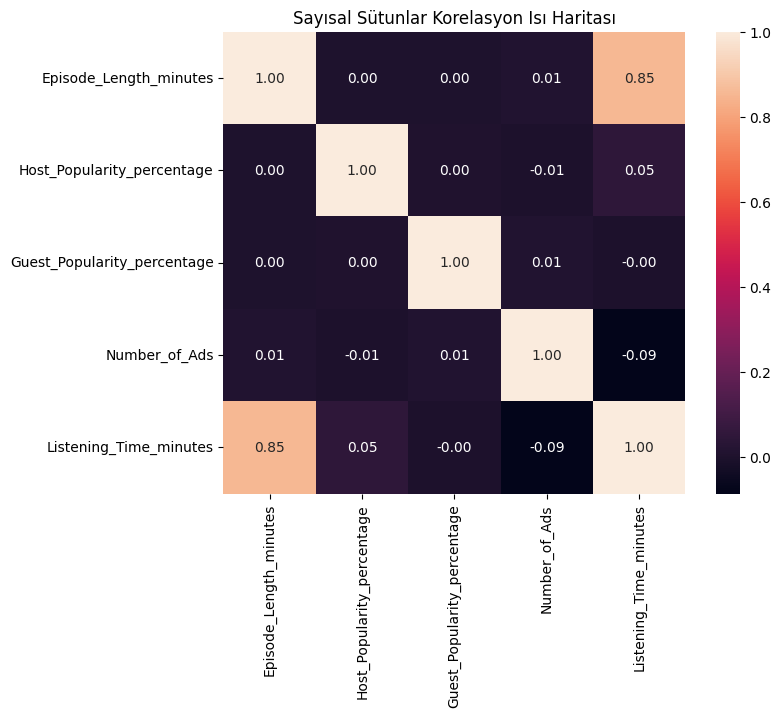

In [31]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Sayısal Sütunlar Korelasyon Isı Haritası")
plt.show()


In [32]:
df["engagement_ratio"] = (
    df["Host_Popularity_percentage"] +
    df["Guest_Popularity_percentage"]
) / 2

df["ads_impact"] = df["Number_of_Ads"] * df["Episode_Length_minutes"]


In [33]:
# Hedef değişken
y = df["Listening_Time_minutes"]

# Özellikler
x = df.drop("Listening_Time_minutes", axis=1)


In [35]:
cat_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(exclude="object").columns

print("Kategorik:", cat_cols)
print("Sayısal:", num_cols)


Kategorik: Index(['Genre', 'Publication_Day', 'Episode_Sentiment'], dtype='object')
Sayısal: Index(['Episode_Length_minutes', 'Host_Popularity_percentage',
       'Guest_Popularity_percentage', 'Number_of_Ads', 'Guest_missing_flag',
       'ads_per_minute', 'host_guest_interaction', 'is_weekend',
       'length_category', 'pub_time_encoded', 'engagement_ratio',
       'ads_impact'],
      dtype='object')


In [36]:
x = pd.get_dummies(x, columns=cat_cols, drop_first=True)


In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


In [40]:
x_train.dtypes


Episode_Length_minutes          float64
Host_Popularity_percentage      float64
Guest_Popularity_percentage     float64
Number_of_Ads                     int64
Guest_missing_flag                int64
ads_per_minute                  float64
host_guest_interaction          float64
is_weekend                        int64
length_category                category
pub_time_encoded                  int64
engagement_ratio                float64
ads_impact                      float64
Genre_Comedy                       bool
Genre_Education                    bool
Genre_Health                       bool
Genre_Lifestyle                    bool
Genre_Music                        bool
Genre_News                         bool
Genre_Sports                       bool
Genre_Technology                   bool
Genre_True Crime                   bool
Publication_Day_Monday             bool
Publication_Day_Saturday           bool
Publication_Day_Sunday             bool
Publication_Day_Thursday           bool


In [41]:
x = x.drop("length_category", axis=1)


In [43]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


In [45]:
from sklearn.metrics import r2_score


In [46]:
from sklearn.linear_model import Lasso

Lass = Lasso(alpha=0.01)
modelL = Lass.fit(x_train, y_train)
tahminL = modelL.predict(x_test)

print("Lasso R2:", r2_score(y_test, tahminL))


Lasso R2: 0.7517837747976559


In [47]:
from sklearn.linear_model import ElasticNet

E = ElasticNet()
modelE = E.fit(x_train, y_train)
tahminE = modelE.predict(x_test)

print("ElasticNet R2:", r2_score(y_test, tahminE))


ElasticNet R2: 0.7494377199310301


In [48]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
modelDT = dt.fit(x_train, y_train)
tahminDT = modelDT.predict(x_test)

print("Decision Tree R2:", r2_score(y_test, tahminDT))


Decision Tree R2: 0.53102954358362


In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
modelRF = rf.fit(x_train, y_train)
tahminRF = modelRF.predict(x_test)

print("Random Forest R2:", r2_score(y_test, tahminRF))


Random Forest R2: 0.7562614760885422


In [51]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
modelGBR = gbr.fit(x_train, y_train)
tahminGBR = modelGBR.predict(x_test)

print("Gradient Boosting R2:", r2_score(y_test, tahminGBR))


Gradient Boosting R2: 0.7545734113486563


In [53]:
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
modelETR = etr.fit(x_train, y_train)
tahminETR = modelETR.predict(x_test)

print("Extra Trees R2:", r2_score(y_test, tahminETR))


Extra Trees R2: 0.7445786381614676


In [55]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

modelXGB = xgb.fit(x_train, y_train)
tahminXGB = modelXGB.predict(x_test)

print("XGBoost R2:", r2_score(y_test, tahminXGB))


XGBoost R2: 0.7546629505168785


## Sonuç


Bu çalışmada podcast dinleme süresinin tahmini için farklı regresyon modelleri karşılaştırılmış ve en yüksek performans Random Forest modeli ile 
𝑅
2
= 0.757
R
2
=0.757 değeri elde edilmiştir. Sonuçlar, veri setinde dinleme süresinin büyük ölçüde doğrusal ilişkilerle açıklanabildiğini, ancak ağaç tabanlı modellerin doğrusal modellere kıyasla sınırlı düzeyde performans artışı sağladığını göstermektedir. Bu durum, model başarısının esas olarak etkili özellik mühendisliği ve uygun veri ön işleme adımlarına bağlı olduğunu ortaya koymaktadır.